# PROYECTO PRACTICO 1
## OBJETIVO GENERAL
### Implementar un flujo de análisis geoespacial en la nube utilizando datos Sentinel-2 de Copernicus Data Space, seleccionando un área de estudio dentro del departamento de Putumayo y comparando espacialmente una condición seca y una condición húmeda mediante el índice NDWI.
OBJETIVOS ESPECIFICOS 

1. Seleccione un área de estudio relevante para su proyecto de investigación. Cargue un archivo vectorial (.geojson, .gpkg o .shp) que defina su área de interés (AOI) y extraiga su geometría.

2. Realice una consulta a la API OData de CDSE para obtener un producto específico de su elección. Seleccione dos fechas de adquisición distintas (por ejemplo, estación seca frente a lluviosa, antes y después de un evento extremo o una comparación interanual).

3. Acceda a las bandas espectrales pertinentes directamente a través de S3 utilizando el sistema de archivos virtual `/vsis3/` sin descargar el producto completo localmente, y aplique una máscara o recorte los conjuntos de datos a su AOI.

4. Calcule una imagen de diferencia o cambio para cuantificar las variaciones espaciales a lo largo del tiempo.
Exporte localmente el ráster de diferencia generado como un archivo GeoTIFF (.tif o .tiff) utilizando `rasterio` o `rioxarray`, asegurando una georreferenciación correcta y la preservación del sistema de referencia espacial (CRS).

5. Visualice la imagen del Estado 1, la imagen del Estado 2 y la imagen de diferencia en un mapa interactivo utilizando `leafmap` con una paleta de colores divergente adecuada (por ejemplo, RdYlGn o coolwarm). Incorpore controles adicionales a la interfaz de `leafmap` para mejorar la usabilidad (por ejemplo, control de pantalla dividida o deslizador de comparación, control de capas, barra de escala, minimapa, herramientas de dibujo o modo de pantalla completa).

# 1. Configuració inicial
## 1.1. Alistar las librerias de base necesarias para el ejercicio
### El objetivo: Importar las librerias necesarias para llevar acabo el ejercicio
La idea dejar el panorama listo en cuanto a los requerimientos del sistema sentral, permisos para trabajar o utilizar la sube,trabajo geooespacial y visualización

In [1]:
#Sistema central
import os #permite interactuar con el sistema operativo, por ejemplo, acceder a variables de entorno, rutas y archivos
import re #permite buscar, identificar y manipular patrones de texto mediante expresiones regulares.
import requests #permite realizar solicitudes HTTP/HTTPS para consultar y descargar información desde servicios web o APIs

#Autenticación en la nube de AWS e interfaz de S3
#estas librerias pueden presentar problemas dependeindo del estado de la internet o de la capasidad de memoria RAM
import boto3 # permite conectarse y trabajar con servicios de Amazon Web Services (AWS), como S3, para autenticar y acceder a archivos almacenados en la nube
from rasterio.session import AWSSession #permite integrar las credenciales y la sesión de AWS de boto3 con Rasterio/GDAL para acceder a datos raster almacenados en servicios S3

# Análisis geooespacial
import numpy as np #permite realizar operaciones numéricas y matemáticas eficientes sobre matrices y arreglos
import glymur #*permite leer y procesar archivos JPEG2000 (.jp2), que es el formato en el que Sentinel-2 almacena muchas de sus bandas.*
import rasterio #permite leer, escribir y procesar datos raster geoespaciales, como imágenes satelitales GeoTIFF o JP2.
from rasterio.windows import from_bounds #permite crear una ventana de lectura de un raster a partir de las coordenadas de los límites de un área de interés (AOI)
from rasterio.mask import mask #permite recortar un raster utilizando la geometría de una capa vectorial
from rasterio.transform import Affine #*define la transformación espacial del raster: convierte filas/columnas del raster en coordenadas.*
from rasterio.crs import CRS #*define el sistema de coordenadas del raster, por ejemplo UTM/WGS84.*
from rasterio.io import MemoryFile #*sirve para crear y manejar temporalmente un raster en la memoria RAM, sin guardarlo como archivo en el disco.*
from rasterio.warp import calculate_default_transform, reproject, Resampling
import geopandas as gpd #permite leer, manipular, transformar y analizar datos vectoriales geoespaciales,
import xml.etree.ElementTree as ET #lee archivos XML, como el MTD_TL.xml de Sentinel-2.

#Visualización
import matplotlib.pyplot as plt #permite crear gráficos y visualizar datos, como mapas, histogramas, curvas y otras figuras.
import leafmap.maplibregl as leafmap #permite crear mapas interactivos y visualizar datos geoespaciales

#Lmacenamiento
from pathlib import Path #maneja rutas y archivos de forma sencilla. Ej.: dónde guardar las imágenes descargadas.
import time #mide tiempos. Ej.: cuánto tarda una descarga.

## 1.2. Credenciales Copernicus
### El objetivo: acceder por medio de las llaves a los datos del ecosistema de Copernicus

In [2]:
#Para ptener las credenciales toca antes acceder a la plataforma de Copernicus y crear las llaves
os.environ["AWS_ACCESS_KEY_ID"] ="V6LPFKBFFK9GERPFBPO0"
os.environ["AWS_SECRET_ACCESS_KEY"] = "Jq4BeOtTeZy8ky4VJRmX9wQHD0ab1jgmNWdBwMkc"
os.environ["AWS_S3_ENDPOINT"] = "eodata.dataspace.copernicus.eu"
os.environ["AWS_VIRTUAL_HOSTING"] = "FALSE"
os.environ["GDAL_HTTP_UNSAFESSL"] = "YES"
os.environ["AWS_HTTPS"] = "YES"
os.environ["GDAL_HTTP_TCP_KEEPALIVE"] = "YES"

# 2. Cargar área de estudio 
## Partí de un límite departamental en EPSG:9377 y definí un AOI más pequeño mediante una herramienta interactiva de selección. Esto permitió reducir el volumen de procesamiento y concentrar el análisis en una ventana espacial manejable
### El objetivo: definir un área de estudio medianete un archivo vectorial
El archivo fucnionará como mascara para delimitar el área geográfica.
Tambien se definirá el sistema de coordenadas del área de estudio, sus geometrías y tablas de atributos

In [3]:
from pathlib import Path #permite trabajar de forma sencilla y segura con rutas de archivos y carpetas

#se trabajara sobre el departamento de Putumayo, shape almacenado en la carpeta de trabajo
root_folder = Path(r"C:\Users\Leo\Documents\GEOPROCESAMIENTO\Proyecto1\Dep_Putumayo")

# Ajusta el nombre exacto de tu archivo .shp
gdf_aoi = gpd.read_file(root_folder / "Departamento_Putumayo.shp")

print("CRS original:", gdf_aoi.crs) #muestra el sistema de coordenadas (CRS) del AOI
print("Número de geometrías:", len(gdf_aoi)) #muestra cuántas geometrías/entidades contiene el AOI.
gdf_aoi.head() #muestra las primeras 5 filas de la tabla de atributos

CRS original: EPSG:9377
Número de geometrías: 1


,DeCodigo,DeNombre,DeArea,DeNorma,Shape_Leng,Shape_Area,Class,geometry
0,86,Putumayo,25701.41141,ConstituciÃ³n PolÃ­tica de Colombia 1991,1.410906e+06,2.570141e+10,1,"POLYGON ((4591376.253 1720501.82, 4591431.122 ..."


### Verificación del área de estudio

<Axes: >

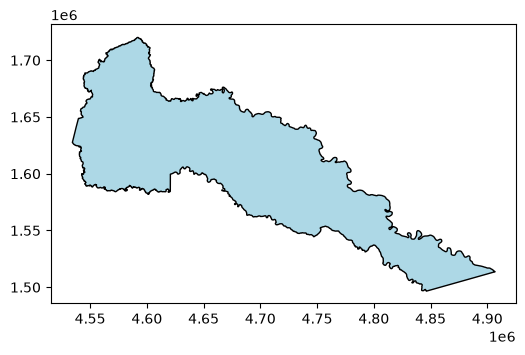

In [4]:
gdf_aoi.plot(figsize=(6,6), edgecolor="black", color="lightblue")

## 2.1 Extrar centroide, esto se utilizará luego en los mapas dinámicos
### El objetivo de este paso es ubicar un punto en el centro del área de estudio para construir mapas dinámicos.
*Debido a que el el departamento de putumayo es muy grande, el mapa dinámico permitirá crear un poligono en el lugar y del tamaño deseado para llevar a cabo el ejercicio*

In [5]:
centroid_point = gdf_aoi.to_crs(epsg=4326).geometry.centroid.iloc[0]
centroid_lat = centroid_point.y
centroid_lon = centroid_point.x
print(f"Centroide: lat={centroid_lat}, lon={centroid_lon}")

Centroide: lat=0.457947122320159, lon=-75.86179021183258


## 2.2. Selección de área de estudio manejable dentro de putumayo

El mapa dinámico e interactivo que se creará a continuación, te va a mostrar un mapa con el contorno de Putumayo en rojo sobre una imagen satelital. En la barra de herramientas del mapa (generalmente a la izquierda o arriba), deberías ver íconos de dibujo (rectángulo, polígono, etc.).

### Dibuja una parcela  sobre la zona de Putumayo que te interese (recomendación: algo de unos 15-25 km de lado, para mantenerlo rápido).

In [6]:
import leafmap ## Permite mapas dinámicos

# Centrar el mapa en Putumayo
centroid_putumayo = gdf_aoi.to_crs(epsg=4326).geometry.centroid.iloc[0]

m_select = leafmap.Map(
    center=[centroid_putumayo.y, centroid_putumayo.x],
    zoom=9
)

# Mostrar el límite del departamento como referencia
#esto perimitira seleccionar una parcela en el área de estudio
m_select.add_gdf(gdf_aoi.to_crs(epsg=4326), layer_name="Putumayo", fill_colors=["#00000000"], style={"color": "red", "weight": 2, "fillOpacity": 0})

# Agregar basemap satelital para ubicarte mejor visualmente
m_select.add_basemap("Esri.WorldImagery")

m_select

Map(center=[0.457947122320159, -75.86179021183258], controls=(ZoomControl(options=['position', 'zoom_in_text',…

### Permitirá tomar el área que dibujaste en m_select y la convierte en un GeoDataFrame, para lueego utilizarlo como área de estudio

In [7]:
if m_select.user_roi is not None: #comprueba si ya existe una geometría dibujada.
    from shapely.geometry import shape
    
    geom = shape(m_select.user_roi["geometry"]) if "geometry" in m_select.user_roi else shape(m_select.user_roi) #convierte la geometría GeoJSON dibujada en una geometría de Shape
    
    gdf_aoi_seleccionado = gpd.GeoDataFrame(
        {"geometry": [geom]}, 
        crs="EPSG:4326"
    ) #queda siendo tu nuevo AOI e área seleccionada
    print("✅ AOI seleccionado correctamente")
    print(gdf_aoi_seleccionado)
else:
    print("⚠️ Aún no has dibujado nada en el mapa") # para verificar si realmente se selecciono una parcela

✅ AOI seleccionado correctamente
                                            geometry
0  POLYGON ((-76.96081 0.4507, -76.96081 0.52383,...


### Visualizaciín del poligono seleccionado para el análisis

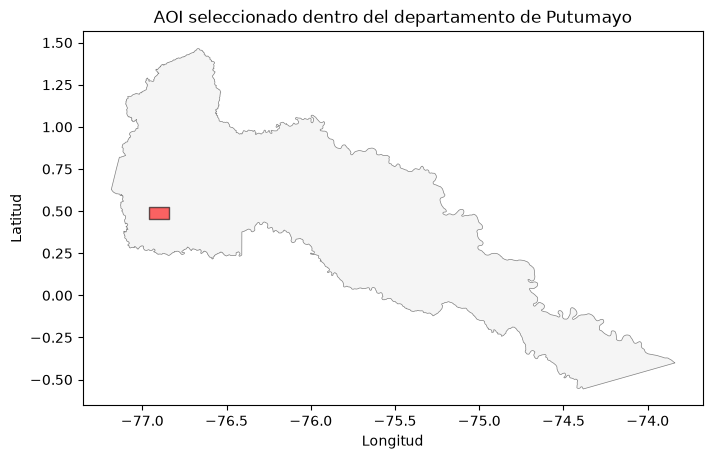

In [8]:
fig, ax = plt.subplots(figsize=(8, 8))

# Mostrar el departamento delputumayo completo como contexto
gdf_aoi.to_crs(epsg=4326).plot(ax=ax, color="whitesmoke", edgecolor="gray", linewidth=0.5)

# Resaltar el AOI seleccionado
gdf_aoi_seleccionado.plot(ax=ax, color="red", edgecolor="black", alpha=0.6)

#etiquetas o elementos de la figura
ax.set_title("AOI seleccionado dentro del departamento de Putumayo")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
plt.show()

## 2.3. Seleccionat los limiter de la parcela AOI
### Esta información se requerirá para que se encuentren dantos de sentienel bajo los imites del área de estudio (poligono previamente generado)

In [9]:
bounds_sel = gdf_aoi_seleccionado.total_bounds
min_lon, min_lat, max_lon, max_lat = bounds_sel
print("Bounding box del AOI seleccionado:", bounds_sel)

Bounding box del AOI seleccionado: [-76.960808   0.450705 -76.842018   0.52383 ]


# 3. Seleccion de datos Sentinel2
## La selección de datos se reliza mendiante la API OData de Copernicus, donde se realiza la consulta del catalogo de datos con los filtros que uno determine.
¿Qué iamgenes sentinel2 existen para la zona, para ese momento y con determinano porcentaje de bunes?
## Una vez se seleccione la escena con OData s3 (Simple Storage Service) accede a los archivos de esa escena para su posterior uso.

### El objetivo de este paso es preparar la conexión con Sentinel-2, localiza los datos de una imagen y obtiene su sistema de coordenadas y ubicación espacial para poder trabajar correctamente con el raster.
Granule: Es la carpeta dentro del producto Sentinel-2 que contiene los datos de una escena y sus metadatos.

In [10]:
#Definir el lugar donde se guardarán las descargas
download_folder = Path(r"C:\Users\Leo\Documents\GEOPROCESAMIENTO\Proyecto1\descargas")
download_folder.mkdir(exist_ok=True) #Esto crea una carpeta "descargas si es que no  se ha creado antes"

#Vinculación con la base de datos S3 de copernicus
s3_client = boto3.client(
    "s3",
    aws_access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    aws_secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"],
    endpoint_url=f"https://{os.environ['AWS_S3_ENDPOINT']}"
)

#Busca la carpeta GRANULE de una imagen 
#A partir de una imagen Sentinel-2, encuentra su carpeta GRANULE, donde están los datos y metadatos de la imagen.
def find_granule_path(s3_path, s3_client):
    prefix = s3_path.lstrip("/eodata/") + "/GRANULE/"
    response = s3_client.list_objects_v2(Bucket="eodata", Prefix=prefix, Delimiter="/")
    folders = response.get("CommonPrefixes", [])
    return folders[0]["Prefix"] if folders else None

#Se obtiene la georreferenciación 
def get_georef_from_xml(xml_path, resolution=10):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    epsg_code = root.find(".//HORIZONTAL_CS_CODE").text
    crs = CRS.from_string(epsg_code)
    for geopos in root.findall(".//Geoposition"):
        if geopos.get("resolution") == str(resolution):
            ulx = float(geopos.find("ULX").text)
            uly = float(geopos.find("ULY").text)
            xdim = float(geopos.find("XDIM").text)
            ydim = float(geopos.find("YDIM").text)
            return crs, Affine(xdim, 0.0, ulx, 0.0, ydim, uly)
    raise ValueError(f"No se encontró geoposición para resolución {resolution}m")


## 3.1. Busca y descarga localmente el MTD_TL.xml de la imagen Sentinel-2, evitando volver a descargarlo si ya existe, para usar sus metadatos de georreferenciación posteriormente.
MTD_TL.xml: Es el archivo de metadatos del Granule que indica el sistema de coordenadas y la ubicación espacial de los píxeles del raster.

In [11]:
#Construye la ubicación del XML en Copernicus
#ndica qué MTD_TL.xml debe buscar dentro del granule
def download_metadata_xml(granule, local_filename):
    """
    Descarga el MTD_TL.xml correspondiente al granule Sentinel-2.
    """
    s3_key = f"{granule}MTD_TL.xml"
    local_path = download_folder / local_filename #Define dónde guardarlo, en este caso en la carpeta de descargas

    if local_path.exists():#verificar si ya lo rienes o no 
        print(f"✔️ Ya existe: {local_filename}")
        return local_path

    inicio = time.time()
#Descarga el XML Lo trae desde Copernicus/S3 a tu computador.
    s3_client.download_file(
        "eodata",
        s3_key,
        str(local_path)
    )

    print(f"✅ Descargado {local_filename} en {time.time() - inicio:.1f}s")

    return local_path

## 3.2. La funcion *"search_sentinel2_odata"* consulta Copernicus y encuentra las imágenes Sentinel-2 que cubren tu AOI, están dentro del período indicado y tienen como máximo el porcentaje de nubes establecido.

In [12]:
# La función search_sentinel2_odata() recibe las coordenadas que delimitan el AOI, 
#las fechas inicial y final del periodo de búsqueda, 
#el porcentaje máximo de nubosidad permitido
#el número máximo de imágenes a obtener.
def search_sentinel2_odata(min_lon, min_lat, max_lon, max_lat, start_date, end_date, max_cloud=10, max_results=20):
    url = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"
    poly = f"POLYGON(({min_lon} {min_lat}, {max_lon} {min_lat}, {max_lon} {max_lat}, {min_lon} {max_lat}, {min_lon} {min_lat}))"
    filter_query = (
        f"Collection/Name eq 'SENTINEL-2' and "
        f"Attributes/StringAttribute/any(att:att/Name eq 'productType' and att/Value eq 'S2MSI2A') and "
        f"Attributes/DoubleAttribute/any(att:att/Name eq 'cloudCover' and att/Value le {max_cloud}) and "
        f"OData.CSC.Intersects(area=geography'SRID=4326;{poly}') and "
        f"ContentDate/Start ge {start_date}T00:00:00.000Z and "
        f"ContentDate/Start le {end_date}T23:59:59.999Z"
    )
    params = {"$filter": filter_query, "$orderby": "ContentDate/Start desc", "$top": max_results}
    response = requests.get(url, params=params)
    data = response.json()
    items = data.get("value", [])
    results = []
    print(f"Encontradas {len(items)} escenas con <{max_cloud}% de nubes.\n" + "="*60)
    for idx, item in enumerate(items):
        s3_path = item.get("S3Path", "")
        date = item.get("ContentDate", {}).get("Start", "").split("T")[0]
        match = re.search(r"_(T\d{2}[A-Z]{3})_", s3_path)
        tile_id = match.group(1) if match else None
        results.append({"index": idx, "date": date, "tile": tile_id, "s3_path": s3_path})
        print(f"[{idx}] 📅 {date} | 🧩 Tile: {tile_id}")
        print(f"    📦 {s3_path}\n")
    return results

## 3.3. Busca una imagen Sentinel-2 de diciembre de 2024 y otra de junio - julio de 2025 que cubran el AOI, aplica los límites de nubosidad establecidos y selecciona la primera imagen encontrada de cada período.

In [40]:
#La función check_tile_covers_aoi evalua si las imagenes de sentinel2 está dentro del área de estudio 
def check_tile_covers_aoi(s3_path, s3_client, gdf_aoi):
    granule = find_granule_path(s3_path, s3_client)
    if granule is None:
        return False, None, None
    key_xml = f"{granule}MTD_TL.xml"
    temp_xml = download_folder / "temp_check.xml"
    try:
        s3_client.download_file("eodata", key_xml, str(temp_xml))
    except Exception:
        return False, None, None
    crs, transform = get_georef_from_xml(temp_xml)
    gdf_utm = gdf_aoi.to_crs(crs)
    minx, miny, maxx, maxy = gdf_utm.total_bounds
    tile_minx = transform.c
    tile_maxx = tile_minx + 10980 * transform.a
    tile_maxy = transform.f
    tile_miny = tile_maxy + 10980 * transform.e
    cubre = (minx >= tile_minx and maxx <= tile_maxx and miny >= tile_miny and maxy <= tile_maxy)
    return cubre, granule, (crs, transform)

# Buscar imagen para cada epoca
# Época seca: diciembre de 2024
#establece una fecha de la epoca y un filtro de nubes
candidatos_seca = search_sentinel2_odata(
    min_lon, min_lat, max_lon, max_lat,
    "2024-12-01", "2025-02-28",
    max_cloud=10,
    max_results=10
)

# Época húmeda: junio de 2025
#establece una fecha de la epoca y un filtro de nubes
candidatos_humeda = search_sentinel2_odata(
    min_lon, min_lat, max_lon, max_lat,
    "2025-06-01", "2025-08-30",
    max_cloud=20,
    max_results=20
)

print(f"Imágenes secas encontradas: {len(candidatos_seca)}")
print(f"Imágenes húmedas encontradas: {len(candidatos_humeda)}")

# SELECCIONAR UNA IMAGEN DE CADA ÉPOCA
# Verificar cuáles candidatos cubren completamente el AOI
candidatos_seca_validos = []
for c in candidatos_seca:
    cubre, granule, georef = check_tile_covers_aoi(
        c["s3_path"],
        s3_client,
        gdf_aoi_seleccionado
    )

    if cubre:
        candidatos_seca_validos.append(c)

candidatos_humeda_validos = []

for c in candidatos_humeda:
    cubre, granule, georef = check_tile_covers_aoi(
        c["s3_path"],
        s3_client,
        gdf_aoi_seleccionado
    )

    if cubre:
        candidatos_humeda_validos.append(c)


# Mostrar resultados
print("Imágenes secas que cubren el AOI:", len(candidatos_seca_validos))
print("Imágenes húmedas que cubren el AOI:", len(candidatos_humeda_validos))

# Seleccionar la primera imagen que sí cubra el AOI
seca_elegida = candidatos_seca_validos[0]
humeda_elegida = candidatos_humeda_validos[0]

# Guardar rutas
s3_path_seca = seca_elegida["s3_path"]
s3_path_humeda = humeda_elegida["s3_path"]

print("\nSeca:", seca_elegida["date"], "|", seca_elegida["tile"])
print("Húmeda:", humeda_elegida["date"], "|", humeda_elegida["tile"])

Encontradas 1 escenas con <10% de nubes.
[0] 📅 2025-01-22 | 🧩 Tile: T18NTF
    📦 /eodata/Sentinel-2/MSI/L2A/2025/01/22/S2C_MSIL2A_20250122T152721_N0511_R025_T18NTF_20250122T184057.SAFE

Encontradas 1 escenas con <20% de nubes.
[0] 📅 2025-08-30 | 🧩 Tile: T18NTF
    📦 /eodata/Sentinel-2/MSI/L2A/2025/08/30/S2C_MSIL2A_20250830T152711_N0511_R025_T18NTF_20250830T201613.SAFE

Imágenes secas encontradas: 1
Imágenes húmedas encontradas: 1
Imágenes secas que cubren el AOI: 1
Imágenes húmedas que cubren el AOI: 1

Seca: 2025-01-22 | T18NTF
Húmeda: 2025-08-30 | T18NTF


# 4. Intento para el uso de S3 en linea
### El obejtivo leer las bandas B03 y B08 de Sentinel-2 para las temporadas seca y húmeda, pero únicamente en la zona correspondiente al AOI seleccionado
### Este codigo suele fallar reiteradamente cuendo la RAM no aguanta

In [ ]:
from rasterio.windows import from_bounds

boto3_session = boto3.Session(
    aws_access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    aws_secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"]
)
endpoint = f"https://{os.environ['AWS_S3_ENDPOINT']}"
rio_session = AWSSession(boto3_session, endpoint_url=endpoint)

def read_windowed_band(url, session, gdf_aoi):
    """Lee solo la ventana de píxeles correspondiente al AOI."""
    with rasterio.Env(session=session, AWS_VIRTUAL_HOSTING="FALSE"):
        with rasterio.open(url) as src:
            gdf_utm = gdf_aoi.to_crs(src.crs)
            bounds = gdf_utm.total_bounds
            window = from_bounds(*bounds, transform=src.transform)
            data = src.read(1, window=window).astype(np.float32)
            transform = src.window_transform(window)
            crs = src.crs
    return data, transform, crs

# Estado 1 (temporada seca)
print("Leyendo Estado 1 (seca)...")
b03_seca, transform_seca, crs_seca = read_windowed_band(url_seca_b03, rio_session, gdf_aoi_seleccionado)
b08_seca, _, _ = read_windowed_band(url_seca_b08, rio_session, gdf_aoi_seleccionado)
print("Shape:", b03_seca.shape)

# Estado 2 (temporada húmeda)
print("Leyendo Estado 2 (húmeda)...")
b03_humeda, transform_humeda, crs_humeda = read_windowed_band(url_humeda_b03, rio_session, gdf_aoi_seleccionado)
b08_humeda, _, _ = read_windowed_band(url_humeda_b08, rio_session, gdf_aoi_seleccionado)
print("Shape:", b03_humeda.shape)

# 5. Alternativa usar las 4 bandas con boto3, mediante la descarga de información

## 5.1 Dado que ahora es necesaria la descarga de información en el computador. Primero debemos garantizar que la carpta de "descargas" esté limpia y no contenga otros archivos jp2 

In [42]:
#Elimina archivos JP2 anteriores de las bandas Sentinel-2
for f in ["seca_B03.jp2", "seca_B08.jp2", "humeda_B03.jp2", "humeda_B08.jp2"]:
    fp = download_folder / f
    if fp.exists():
        fp.unlink()
        print(f"🗑️ Eliminado: {f}")

## 5.2. Encontrar las rutas exactas (Key) de las bandas B03 y B08 dentro de los productos Sentinel-2 seleccionados
Este fragmento busca dentro de cada producto Sentinel-2 las dos bandas necesarias para calcular el NDWI: B03 y B08.

In [43]:
#la función get_band_key recibe la ruta del producto, la banda que buscas (B03 o B08) y la conexión S3.
def get_band_key(s3_path, band_name, s3_client):
    """Lista el contenido real de IMG_DATA/R10m y devuelve la key exacta de la banda pedida."""
    granule = find_granule_path(s3_path, s3_client)
    prefix = f"{granule}IMG_DATA/R10m/"
    response = s3_client.list_objects_v2(Bucket="eodata", Prefix=prefix)
    
    for obj in response.get("Contents", []):
        if obj["Key"].endswith(f"_{band_name}_10m.jp2"):
            return obj["Key"], granule
    return None, granule

#Selección de bandas junto con la información geanule
key_seca_b03, granule_seca = get_band_key(s3_path_seca, "B03", s3_client)
key_seca_b08, _ = get_band_key(s3_path_seca, "B08", s3_client)
key_humeda_b03, granule_humeda = get_band_key(s3_path_humeda, "B03", s3_client)
key_humeda_b08, _ = get_band_key(s3_path_humeda, "B08", s3_client)

#comprueba la selección
print("Seca B03:", key_seca_b03)
print("Seca B08:", key_seca_b08)
print("Húmeda B03:", key_humeda_b03)
print("Húmeda B08:", key_humeda_b08)

Seca B03: Sentinel-2/MSI/L2A/2025/01/22/S2C_MSIL2A_20250122T152721_N0511_R025_T18NTF_20250122T184057.SAFE/GRANULE/L2A_T18NTF_A001997_20250122T152858/IMG_DATA/R10m/T18NTF_20250122T152721_B03_10m.jp2
Seca B08: Sentinel-2/MSI/L2A/2025/01/22/S2C_MSIL2A_20250122T152721_N0511_R025_T18NTF_20250122T184057.SAFE/GRANULE/L2A_T18NTF_A001997_20250122T152858/IMG_DATA/R10m/T18NTF_20250122T152721_B08_10m.jp2
Húmeda B03: Sentinel-2/MSI/L2A/2025/08/30/S2C_MSIL2A_20250830T152711_N0511_R025_T18NTF_20250830T201613.SAFE/GRANULE/L2A_T18NTF_A005143_20250830T152711/IMG_DATA/R10m/T18NTF_20250830T152711_B03_10m.jp2
Húmeda B08: Sentinel-2/MSI/L2A/2025/08/30/S2C_MSIL2A_20250830T152711_N0511_R025_T18NTF_20250830T201613.SAFE/GRANULE/L2A_T18NTF_A005143_20250830T152711/IMG_DATA/R10m/T18NTF_20250830T152711_B08_10m.jp2


## 5.3. Descarga desde Copernicuslas cuatro bandas Sentinel-2 seleccionadas (B03 y B08 de las temporadas seca y húmeda) y guardarlas localmente en tu computador
### La descarga la hace en formato jp2.

In [44]:
#se encarga de descargar una banda específica en la carpeta de descargas
def download_band(s3_key, local_filename):
    local_path = download_folder / local_filename
    if local_path.exists():
        print(f"✔️ Ya existe: {local_filename}")
        return local_path
    inicio = time.time()
    s3_client.download_file("eodata", s3_key, str(local_path))
    print(f"✅ Descargado {local_filename} en {time.time()-inicio:.1f}s")
    return local_path

# descarga
path_seca_b03 = download_band(key_seca_b03, "seca_B03.jp2")
path_seca_b08 = download_band(key_seca_b08, "seca_B08.jp2")
path_humeda_b03 = download_band(key_humeda_b03, "humeda_B03.jp2")
path_humeda_b08 = download_band(key_humeda_b08, "humeda_B08.jp2")

✅ Descargado seca_B03.jp2 en 8.8s
✅ Descargado seca_B08.jp2 en 10.4s
✅ Descargado humeda_B03.jp2 en 7.6s
✅ Descargado humeda_B08.jp2 en 6.2s


# 6. Calculo del del índice NDWI 
## 6.1 Tenemos que leer las cuatro imagenes para convertirlas en matrices NumPy y poder realizar posteriormente cálculos y análisis sobre sus píxeles.
### El NDWI (Índice de Diferencia Normalizada del Agua) es un índice espectral que resalta la presencia y distribución del agua y permite identificar cambios en la humedad superficial, utilizando principalmente las bandas verde (B03) y NIR (B08) de Sentinel-2.
NDWI = (B03-B08)/ B03+ B08

El agua suele reflejar más en B03 que en B08, por eso el NDWI tiende a presentar valores positivos sobre superficies de agua.

In [45]:
#crea la función read_jp2_glymur que lee las imagenes para luego convertiralas en matrices 
def read_jp2_glymur(local_path):
    jp2 = glymur.Jp2k(str(local_path))
    return jp2[:].astype(np.float32)

print("Leyendo bandas...")
b03_seca_full = read_jp2_glymur(path_seca_b03)
b08_seca_full = read_jp2_glymur(path_seca_b08)
b03_humeda_full = read_jp2_glymur(path_humeda_b03)
b08_humeda_full = read_jp2_glymur(path_humeda_b08)

#Verificación de las namdas leídas
print("✅ Bandas leídas. Shape:", b03_seca_full.shape)

Leyendo bandas...
✅ Bandas leídas. Shape: (10980, 10980)


## 6.2. Obtener georreferenciación desde el XML 
### Descarga los metadatos de las dos imágenes Sentinel-2 y extrae su sistema de coordenadas y georreferenciación para poder ubicarlas y recortarlas correctamente sobre el AOI.

In [46]:
#Esa parte elimina los archivos XML antiguos antes de volver a descargarlos.
for nombre in ["seca_MTD_TL.xml", "humeda_MTD_TL.xml"]:
    archivo = download_folder / nombre
    if archivo.exists():
        archivo.unlink()
        
# descarga de archivos MTD_TL.xml
xml_seca = download_metadata_xml(granule_seca, "seca_MTD_TL.xml")
xml_humeda = download_metadata_xml(granule_humeda, "humeda_MTD_TL.xml")

crs_seca, transform_seca = get_georef_from_xml(xml_seca)
crs_humeda, transform_humeda = get_georef_from_xml(xml_humeda)

print("CRS:", crs_seca)
print("Transform seca:", transform_seca)

✅ Descargado seca_MTD_TL.xml en 0.5s
✅ Descargado humeda_MTD_TL.xml en 0.5s
CRS: EPSG:32618
Transform seca: | 10.00, 0.00, 199980.00|
| 0.00,-10.00, 100020.00|
| 0.00, 0.00, 1.00|


## 6.3. Recortar las bandas completas a tu AOI
### Convierte temporalmente la banda en un raster georreferenciado, la recorta usando el AOI y devuelve únicamente los píxeles del área de estudio junto con su nueva ubicación espacial.

In [57]:
def clip_array_to_aoi(array, transform, crs, gdf_aoi):
    gdf_aoi = gdf_aoi.to_crs(crs)

    with MemoryFile() as memfile:
        with memfile.open(
            driver="GTiff",
            height=array.shape[0],
            width=array.shape[1],
            count=1,
            dtype=array.dtype,
            crs=crs,
            transform=transform
        ) as src:
            src.write(array, 1)

            clipped, out_transform = mask(
                src,
                gdf_aoi.geometry,
                crop=True
            )

    return clipped[0], out_transform

### Recorta B03 y B08 de las imágenes seca y húmeda al AOI, dejando únicamente los píxeles del área de estudio que posteriormente se utilizarán para calcular el NDWI.

In [48]:
#recorte 
b03_seca, out_transform = clip_array_to_aoi(b03_seca_full, transform_seca, crs_seca, gdf_aoi_seleccionado)
b08_seca, _ = clip_array_to_aoi(b08_seca_full, transform_seca, crs_seca, gdf_aoi_seleccionado)
b03_humeda, _ = clip_array_to_aoi(b03_humeda_full, transform_humeda, crs_humeda, gdf_aoi_seleccionado)
b08_humeda, _ = clip_array_to_aoi(b08_humeda_full, transform_humeda, crs_humeda, gdf_aoi_seleccionado)

#Comprovación del recorte
print("Shape recortado B03 seca:", b03_seca.shape)
print("Shape recortado B03 húmeda:", b03_humeda.shape)

Shape recortado B03 seca: (810, 1324)
Shape recortado B03 húmeda: (810, 1324)


## 6.4. Calcular NDWI para cada fecha

In [49]:
def calc_ndwi(green, nir):
    return (green - nir) / (green + nir + 1e-10)  # "1e-10" evita división por cero como

ndwi_seca = calc_ndwi(b03_seca, b08_seca)
ndwi_humeda = calc_ndwi(b03_humeda, b08_humeda)

#Comprovación 
print("NDWI seca - min/max:", ndwi_seca.min(), ndwi_seca.max())
print("NDWI húmeda - min/max:", ndwi_humeda.min(), ndwi_humeda.max())

NDWI seca - min/max: -0.6249576 0.09696376
NDWI húmeda - min/max: -0.6425365 0.17752808


### Visualización de los índices para cada epoca

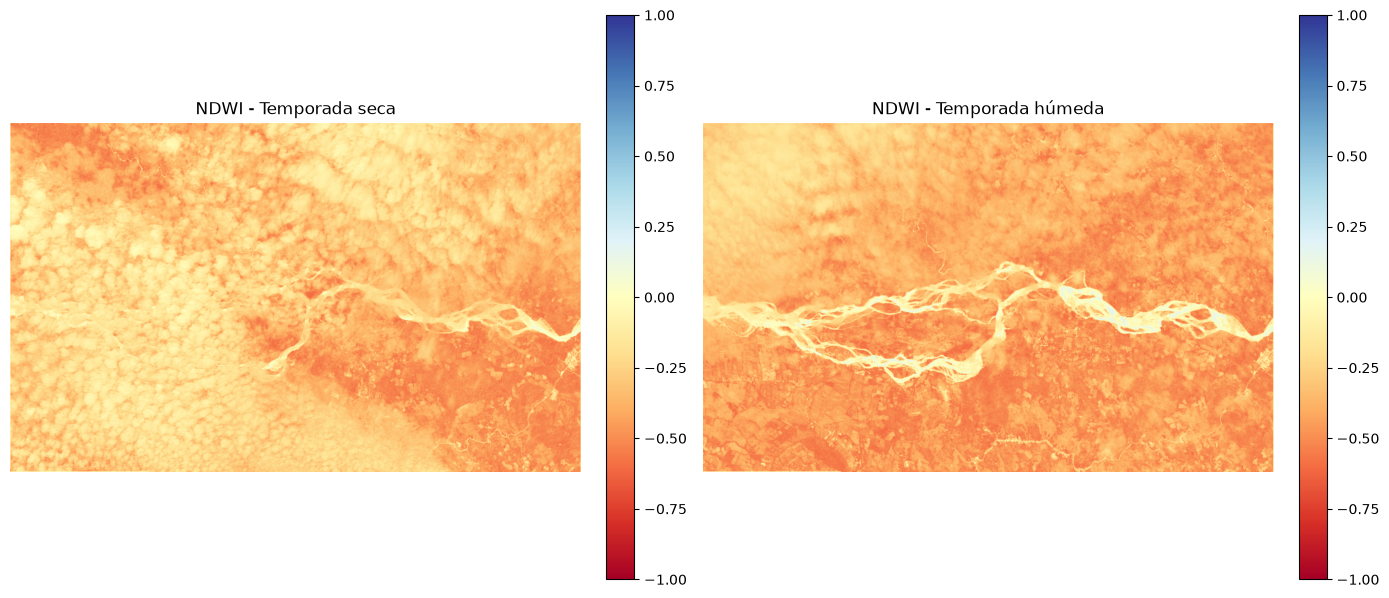

In [50]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# NDWI temporada seca
im1 = axes[0].imshow(ndwi_seca, cmap="RdYlBu", vmin=-1, vmax=1)
axes[0].set_title("NDWI - Temporada seca")
axes[0].axis("off")
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# NDWI temporada húmeda
im2 = axes[1].imshow(ndwi_humeda, cmap="RdYlBu", vmin=-1, vmax=1)
axes[1].set_title("NDWI - Temporada húmeda")
axes[1].axis("off")
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# 7.Calcular la imagen de diferencia (húmeda − seca)

In [51]:
ndwi_diff = ndwi_humeda - ndwi_seca
print("Diferencia - min/max:", ndwi_diff.min(), ndwi_diff.max())

Diferencia - min/max: -0.56012434 0.6268461


### Vusualización
−0,6 → disminución del NDWI de hasta 0,6 unidades.

0 → prácticamente no hubo cambio.

+0,6 → aumento del NDWI de hasta 0,6 unidades.

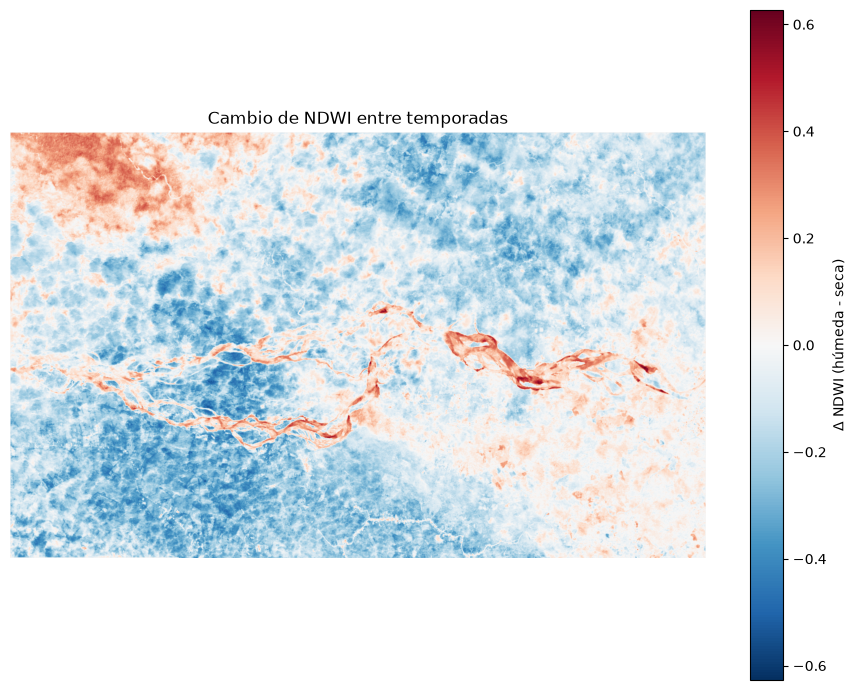

In [52]:
# Escala simétrica alrededor de 0
vmax = max(abs(ndwi_diff.min()), abs(ndwi_diff.max()))

plt.figure(figsize=(9, 7))

im = plt.imshow(
    ndwi_diff,
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax
)

plt.colorbar(im, label="Δ NDWI (húmeda - seca)")
plt.title("Cambio de NDWI entre temporadas")
plt.axis("off")

plt.tight_layout()
plt.show()

## 7.2. Estadísticas descriptivas + histograma de los resultados del índice y su diferencia

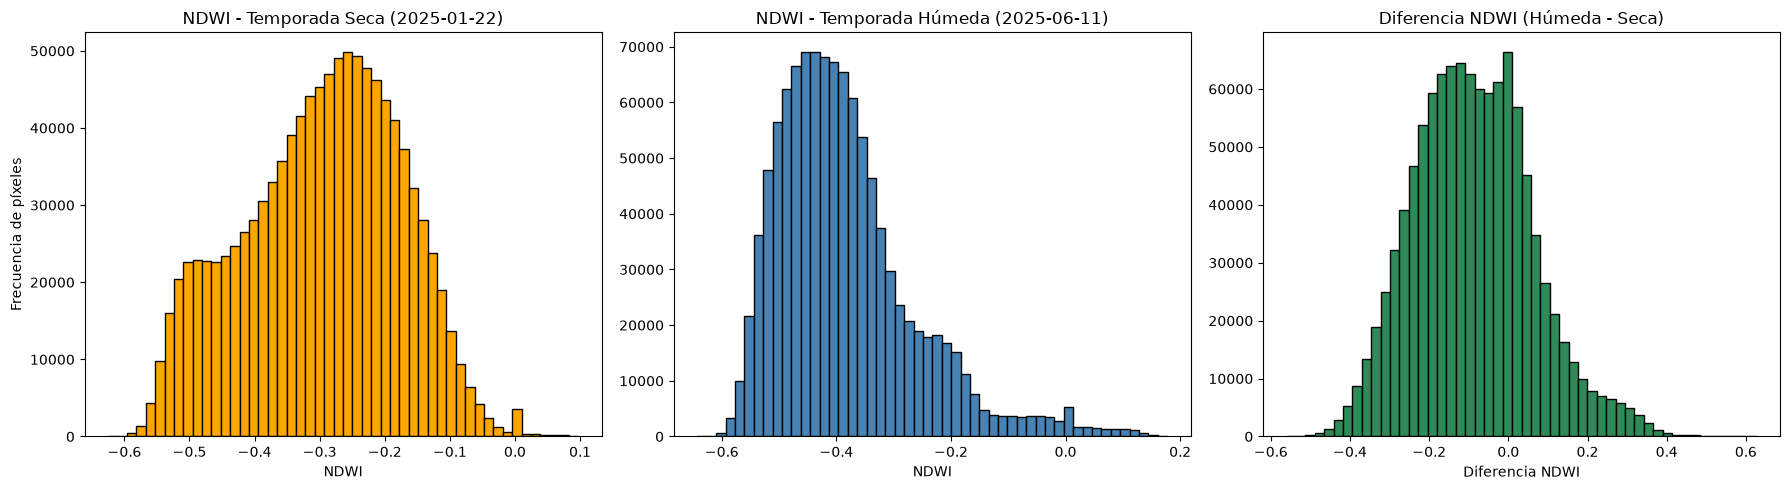

--- Estadísticas descriptivas ---

NDWI Seca:
  Media: -0.2967
  Mínimo: -0.6250
  Máximo: 0.0970
  Desv. estándar: 0.1208

NDWI Húmeda:
  Media: -0.3853
  Mínimo: -0.6425
  Máximo: 0.1775
  Desv. estándar: 0.1210

Diferencia:
  Media: -0.0885
  Mínimo: -0.5601
  Máximo: 0.6268
  Desv. estándar: 0.1495



In [53]:
#Importar librería que permite crear los gráficos.
import matplotlib.pyplot as plt
#Crea una ventana con 3 gráficos organizados horizontalmente. para el grafico de la temporada seca, humeda y la diferencia
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma NDWI temporada seca
axes[0].hist(ndwi_seca.flatten(), bins=50, color="orange", edgecolor="black")
axes[0].set_title("NDWI - Temporada Seca (2025-01-22)")
axes[0].set_xlabel("NDWI")
axes[0].set_ylabel("Frecuencia de píxeles")

# Histograma NDWI temporada húmeda
axes[1].hist(ndwi_humeda.flatten(), bins=50, color="steelblue", edgecolor="black")
axes[1].set_title("NDWI - Temporada Húmeda (2025-06-11)")
axes[1].set_xlabel("NDWI")

# Histograma de la diferencia
axes[2].hist(ndwi_diff.flatten(), bins=50, color="seagreen", edgecolor="black")
axes[2].set_title("Diferencia NDWI (Húmeda - Seca)")
axes[2].set_xlabel("Diferencia NDWI")

plt.tight_layout()
plt.show()

# Estadísticas descriptivas de las 3 capas
print("--- Estadísticas descriptivas ---\n")
#Lista de estadísticos
for nombre, arr in [("NDWI Seca", ndwi_seca), ("NDWI Húmeda", ndwi_humeda), ("Diferencia", ndwi_diff)]:
    print(f"{nombre}:")
    print(f"  Media: {arr.mean():.4f}")
    print(f"  Mínimo: {arr.min():.4f}")
    print(f"  Máximo: {arr.max():.4f}")
    print(f"  Desv. estándar: {arr.std():.4f}\n")

## 7.3. Visualización de resultados geográficos 
### Primero los datos de las imagenes tienen que pasarce a formato GeoTIF

In [54]:
# Carpeta de salida
output_folder = r"C:\Users\Leo\Documents\GEOPROCESAMIENTO\Proyecto1\descargas"

def export_geotiff(array, transform, crs, output_path):
    
    # CRS de destino: Colombia - Origen Nacional
    dst_crs = "EPSG:9377"

    # Calcular nueva transformación y dimensiones
    dst_transform, dst_width, dst_height = calculate_default_transform(
        crs,
        dst_crs,
        array.shape[1],
        array.shape[0],
        *rasterio.transform.array_bounds(
            array.shape[0],
            array.shape[1],
            transform
        )
    )

    # Crear raster reproyectado
    dst_array = np.empty((dst_height, dst_width), dtype=np.float32)

    reproject(
        source=array.astype(np.float32),
        destination=dst_array,
        src_transform=transform,
        src_crs=crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=Resampling.bilinear
    )

    # Metadatos
    meta = {
        "driver": "GTiff",
        "height": dst_height,
        "width": dst_width,
        "count": 1,
        "dtype": "float32",
        "crs": dst_crs,
        "transform": dst_transform,
    }

    # Exportar
    with rasterio.open(output_path, "w", **meta) as dst:
        dst.write(dst_array, 1)

    print(f"✅ Exportado: {output_path}")
    print(f"   CRS: {dst_crs}")
    print(f"   Tamaño: {dst_width} × {dst_height}")


# Rutas completas
ruta_seca = os.path.join(output_folder, "ndwi_estado1_seca.tif")
ruta_humeda = os.path.join(output_folder, "ndwi_estado2_humeda.tif")
ruta_diff = os.path.join(output_folder, "ndwi_diferencia.tif")


# Exportar los tres productos
export_geotiff(
    ndwi_seca,
    out_transform,
    crs_seca,
    ruta_seca
)

export_geotiff(
    ndwi_humeda,
    out_transform,
    crs_seca,
    ruta_humeda
)

export_geotiff(
    ndwi_diff,
    out_transform,
    crs_seca,
    ruta_diff
)

✅ Exportado: C:\Users\Leo\Documents\GEOPROCESAMIENTO\Proyecto1\descargas\ndwi_estado1_seca.tif
   CRS: EPSG:9377
   Tamaño: 1324 × 810
✅ Exportado: C:\Users\Leo\Documents\GEOPROCESAMIENTO\Proyecto1\descargas\ndwi_estado2_humeda.tif
   CRS: EPSG:9377
   Tamaño: 1324 × 810
✅ Exportado: C:\Users\Leo\Documents\GEOPROCESAMIENTO\Proyecto1\descargas\ndwi_diferencia.tif
   CRS: EPSG:9377
   Tamaño: 1324 × 810


### Visualización de las capas 1
### Permite visualizar cada uno de los tres resultados

In [58]:
centroid_aoi = gdf_aoi_seleccionado.geometry.iloc[0].centroid
m2 = leafmap.Map(
    center=[centroid_aoi.y, centroid_aoi.x],
    zoom=13
)

m2.add_basemap("Esri.WorldImagery")

m2.add_raster(
    os.path.join(output_folder, "ndwi_estado1_seca.tif"),
    colormap="Blues",
    layer_name="Estado 1 - NDWI Seca",
    opacity=0.8
)

m2.add_raster(
    os.path.join(output_folder, "ndwi_estado2_humeda.tif"),
    colormap="Blues",
    layer_name="Estado 2 - NDWI Húmeda",
    opacity=0.8
)

m2.add_raster(
    os.path.join(output_folder, "ndwi_diferencia.tif"),
    colormap="RdYlGn",
    layer_name="Diferencia NDWI",
    opacity=0.8
)

m2

Map(center=[0.48731099999999994, -76.9014135], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoo…

### Visualización de las capas 2 con la herramienta de spit
### Permite visualizar cada uno de los tres resultados de la temporada seca y húmeda mediante mediante la herramienta de split

In [59]:
import leafmap.leafmap as leafmap
m2_split = leafmap.Map(
    center=[centroid_aoi.y, centroid_aoi.x],
    zoom=13
)

m2_split.split_map(
    left_layer=os.path.join(
        output_folder, "ndwi_estado1_seca.tif"
    ),
    right_layer=os.path.join(
        output_folder, "ndwi_estado2_humeda.tif"
    ),
    left_label="🌵 Temporada Seca",
    right_label="🌧️ Temporada Húmeda"
)

m2_split

Map(center=[0.4872675, -76.901413], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title'…

# 8. Descargas
Para ver los resultados : https://drive.google.com/drive/folders/1gOHN72Wv3srx3a0S6zfsMBTkexLGYIfV?usp=sharing